<a href="https://colab.research.google.com/github/RobertM1725/CMSC206_DataGeeks_GroupProjectFinal/blob/main/RMiller_CMSC206_GroupProjectFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First five rows:
   Marital Status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2                    

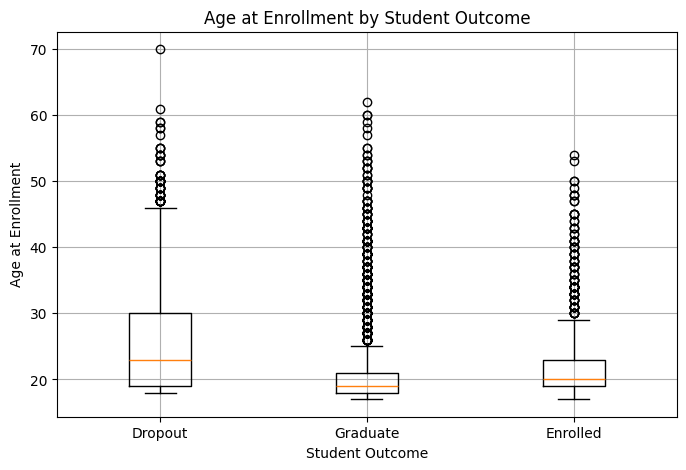

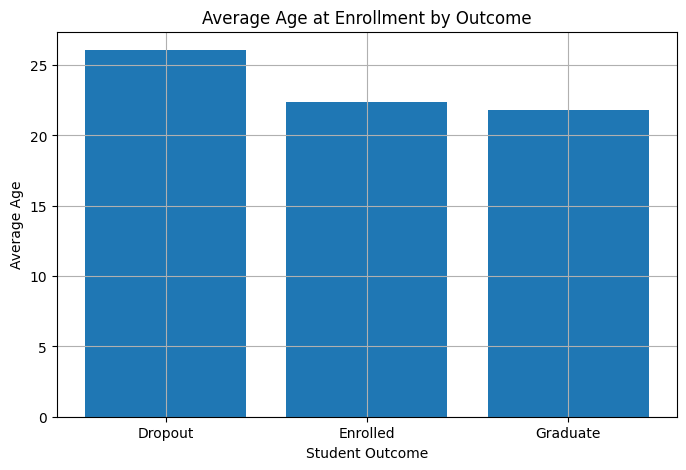

Optimization terminated successfully.
         Current function value: 0.633603
         Iterations 5
Age at Enrollment Logistic Regression:
                           Logit Regression Results                           
Dep. Variable:        Graduate_Status   No. Observations:                 3630
Model:                          Logit   Df Residuals:                     3628
Method:                           MLE   Df Model:                            1
Date:                Mon, 04 May 2026   Pseudo R-squ.:                 0.05347
Time:                        20:33:56   Log-Likelihood:                -2300.0
converged:                       True   LL-Null:                       -2429.9
Covariance Type:            nonrobust   LLR p-value:                 1.839e-58
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.1620      0.119     18.150     

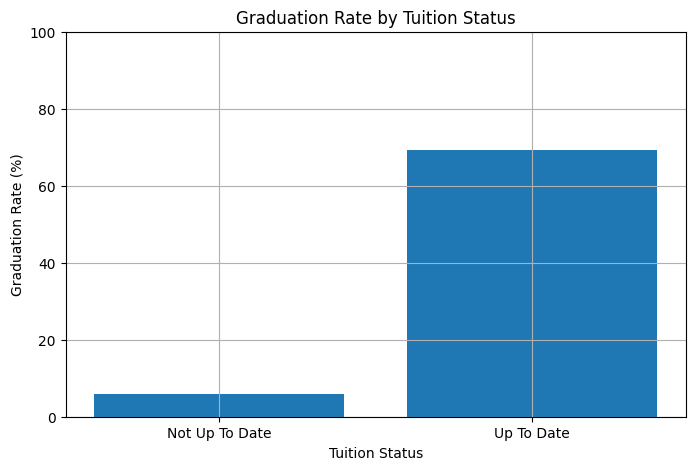

Optimization terminated successfully.
         Current function value: 0.502154
         Iterations 7
Academic and Financial Factors Logistic Regression:
                           Logit Regression Results                           
Dep. Variable:        Graduate_Status   No. Observations:                 3630
Model:                          Logit   Df Residuals:                     3624
Method:                           MLE   Df Model:                            5
Date:                Mon, 04 May 2026   Pseudo R-squ.:                  0.2498
Time:                        20:33:56   Log-Likelihood:                -1822.8
converged:                       True   LL-Null:                       -2429.9
Covariance Type:            nonrobust   LLR p-value:                2.491e-260
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -3.

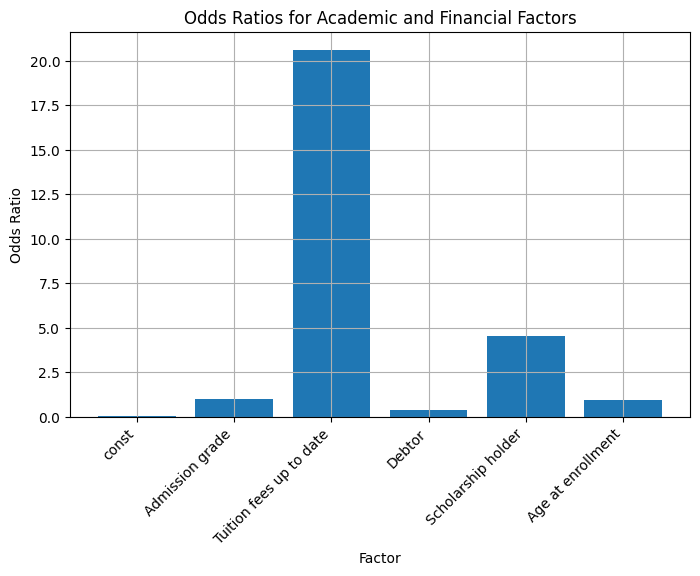

Model accuracy:
0.739

Model coefficients:
Admission grade : 0.018910464152253465
Tuition fees up to date : 3.0885387641474322
Debtor : -0.6763266785731312
Scholarship holder : 1.4753467907544948
Age at enrollment : -0.048827636856629275



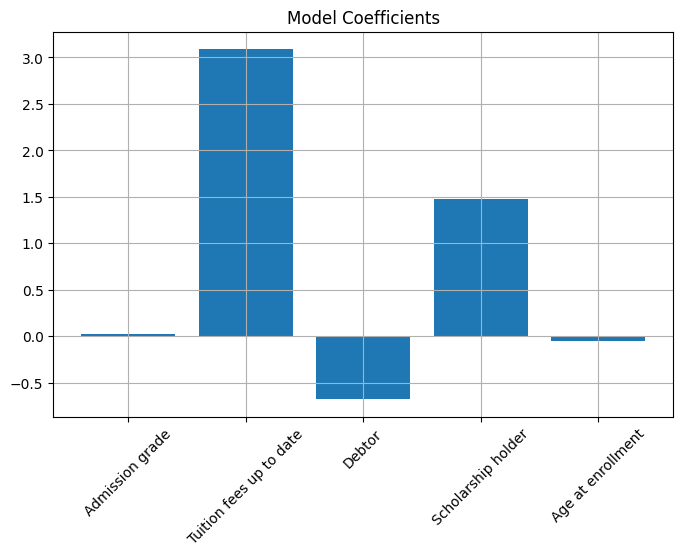


REST Countries API Information (To showcase API usage and JSON processing):
Country: Portugal
Capital: Lisbon
Region: Europe
Population: 10749635
Languages: {'por': 'Portuguese'}

Robert Miller Main Findings:
1. Pandas was used to load and organize the dataset into dataframes.
2. Matplotlib was used to create boxplots and bar charts for age and tuition comparisons.
3. Statsmodels and Scikit-learn were used to run logistic regression models.
4. The REST Countries API was used and JSON data was processed using response.json().
5. Age, tuition status, and financial factors all influenced student outcomes.


In [5]:
# Robert Miller, Robert Gravatt, Karen P, Konara M
# Professor Thai
# CMSC 206 - Group Project Final (Data Geeks)
# 5/4/2026

!pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import statsmodels.api as sm


def loadData():

    student_data = fetch_ucirepo(id=697)

    X = student_data.data.features
    y = student_data.data.targets

    df = X.copy()
    df["Target"] = y   # add outcome column to dataframe

    print("First five rows:")
    print(df.head())
    print()

    print("Dataset shape:")
    print(df.shape)
    print()

    print("Student outcomes:")
    print(df["Target"].value_counts())   # count how many in each category
    print()

    # remove students still enrolled (only want graduate vs dropout)
    df_binary = df[df["Target"] != "Enrolled"].copy()

    # convert text outcome to numbers for modeling
    df_binary["Graduate_Status"] = df_binary["Target"].map({
        "Graduate": 1,
        "Dropout": 0
    })

    print("Graduate and dropout counts:")
    print(df_binary["Target"].value_counts())
    print()

    return df, df_binary


def ageQuestion(df, df_binary):

    # split ages based on outcome
    dropout_ages = df[df["Target"] == "Dropout"]["Age at enrollment"]
    graduate_ages = df[df["Target"] == "Graduate"]["Age at enrollment"]
    enrolled_ages = df[df["Target"] == "Enrolled"]["Age at enrollment"]

    print("Average age by outcome:")
    print(df.groupby("Target")["Age at enrollment"].mean())  # avg age per group
    print()

    plt.figure(figsize=(8, 5))
    plt.boxplot(
        [dropout_ages, graduate_ages, enrolled_ages],
        tick_labels=["Dropout", "Graduate", "Enrolled"]
    )
    plt.title("Age at Enrollment by Student Outcome")
    plt.xlabel("Student Outcome")
    plt.ylabel("Age at Enrollment")
    plt.grid(True)
    plt.show()

    age_means = df.groupby("Target")["Age at enrollment"].mean()

    plt.figure(figsize=(8, 5))
    plt.bar(age_means.index, age_means.values)   # bar chart of average ages
    plt.title("Average Age at Enrollment by Outcome")
    plt.xlabel("Student Outcome")
    plt.ylabel("Average Age")
    plt.grid(True)
    plt.show()

    # logistic regression using only age
    age_x = df_binary[["Age at enrollment"]]   # predictor
    age_y = df_binary["Graduate_Status"]       # result

    age_x = sm.add_constant(age_x)

    age_model = sm.Logit(age_y, age_x)
    age_result = age_model.fit()

    print("Age at Enrollment Logistic Regression:")
    print(age_result.summary())
    print()

    age_odds = np.exp(age_result.params)   # convert to odds ratio

    print("Age Odds Ratio:")
    print(age_odds)
    print()


def tuitionQuestion(df_binary):

    # filter rows where tuition is up to date
    tuition_yes = df_binary[df_binary["Tuition fees up to date"] == 1]

    # filter rows where tuition is NOT up to date
    tuition_no = df_binary[df_binary["Tuition fees up to date"] == 0]

    # average of 1/0 gives graduation rate
    tuition_yes_grad_rate = tuition_yes["Graduate_Status"].mean() * 100
    tuition_no_grad_rate = tuition_no["Graduate_Status"].mean() * 100

    print("Graduation rate for students with tuition up to date:")
    print(round(tuition_yes_grad_rate, 2), "%")
    print()

    print("Graduation rate for students without tuition up to date:")
    print(round(tuition_no_grad_rate, 2), "%")
    print()

    tuition_labels = ["Not Up To Date", "Up To Date"]
    tuition_rates = [tuition_no_grad_rate, tuition_yes_grad_rate]

    plt.figure(figsize=(8, 5))
    plt.bar(tuition_labels, tuition_rates)
    plt.title("Graduation Rate by Tuition Status")
    plt.xlabel("Tuition Status")
    plt.ylabel("Graduation Rate (%)")
    plt.ylim(0, 100)
    plt.grid(True)
    plt.show()


def academicVsFinancialQuestion(df_binary):

    # select key variables for comparison
    selected_features = df_binary[
        [
            "Admission grade",
            "Tuition fees up to date",
            "Debtor",
            "Scholarship holder",
            "Age at enrollment"
        ]
    ]

    selected_target = df_binary["Graduate_Status"]

    selected_features_const = sm.add_constant(selected_features)

    main_model = sm.Logit(selected_target, selected_features_const)
    main_result = main_model.fit()

    print("Academic and Financial Factors Logistic Regression:")
    print(main_result.summary())
    print()

    main_odds = np.exp(main_result.params)   # odds ratios

    print("Odds Ratios:")
    print(main_odds)
    print()

    plt.figure(figsize=(8, 5))
    plt.bar(main_odds.index, main_odds.values)
    plt.title("Odds Ratios for Academic and Financial Factors")
    plt.xlabel("Factor")
    plt.ylabel("Odds Ratio")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True)
    plt.show()


def sklearnModel(df_binary):

    # choose columns for model
    X = df_binary[
        [
            "Admission grade",
            "Tuition fees up to date",
            "Debtor",
            "Scholarship holder",
            "Age at enrollment"
        ]
    ]

    y = df_binary["Graduate_Status"]

    # split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)   # train model

    preds = model.predict(X_test)   # make predictions

    acc = accuracy_score(y_test, preds)

    print("Model accuracy:")
    print(round(acc, 4))
    print()

    print("Model coefficients:")
    for i in range(len(X.columns)):
        print(X.columns[i], ":", model.coef_[0][i])
    print()

    plt.figure(figsize=(8,5))
    plt.bar(X.columns, model.coef_[0])
    plt.title("Model Coefficients")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()


def apiAndJson():

    url = "https://restcountries.com/v3.1/name/portugal?fullText=true"

    try:
        response = requests.get(url)   # send API request
        country_data = response.json()   # convert JSON to python

        print()
        print("REST Countries API Information (To showcase API usage and JSON processing):")
        print("Country:", country_data[0]["name"]["common"])   # access nested data
        print("Capital:", country_data[0]["capital"][0])
        print("Region:", country_data[0]["region"])
        print("Population:", country_data[0]["population"])
        print("Languages:", country_data[0]["languages"])
        print()

    except:
        print("The API request did not work.")


def printFindings():

    print("Robert Miller Main Findings:")
    print("1. Pandas was used to load and organize the dataset into dataframes.")
    print("2. Matplotlib was used to create boxplots and bar charts for age and tuition comparisons.")
    print("3. Statsmodels and Scikit-learn were used to run logistic regression models.")
    print("4. The REST Countries API was used and JSON data was processed using response.json().")
    print("5. Age, tuition status, and financial factors all influenced student outcomes.")


def main():

    df, df_binary = loadData()

    ageQuestion(df, df_binary)
    tuitionQuestion(df_binary)
    academicVsFinancialQuestion(df_binary)
    sklearnModel(df_binary)
    apiAndJson()
    printFindings()


main()